# 1. Load Dataset

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load Dataset

In [32]:
df = pd.read_csv("/content/spam_or_not_spam.csv")
df.dropna(subset=['email', 'label'], inplace=True)

X = df['email']
y = df['label']

# Train-Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF Feature Extraction

In [34]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()

# Function (Sigmoid)

In [35]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Hyperparameters

In [36]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
epochs = 10

train_loss_history = {}
test_loss_history = {}
train_acc_history = {}
test_acc_history = {}
final_models = {}

# Training Loop

In [ ]:
# Logistic Regression Training with Different Learning Rates
for lr in learning_rates:

    # 1️⃣ Initialize Parameters (Weights & Bias)
    w = np.zeros(X_train_tfidf.shape[1])   # Weight vector
    b = 0                                  # Bias term

    train_loss_list = []
    test_loss_list = []
    train_acc_list = []
    test_acc_list = []

    # 2️⃣ Epoch Loop
    for epoch in range(epochs):

        total_train_loss = 0

        # 3️⃣ Training Phase (Sample-wise Gradient Descent)
        for x, y_true in zip(X_train_tfidf, y_train):

            #  Forward Pass
            # Linear Model: z = wx + b
            z = np.dot(x, w) + b

            # Sigmoid Activation
            y_pred = sigmoid(z)

            #  Loss Function Used

            loss = -(y_true*np.log(y_pred + 1e-9) +
                     (1-y_true)*np.log(1-y_pred + 1e-9))

            total_train_loss += loss

            #  Backward Pass (Gradient Computation)
            error = y_pred - y_true

            # Gradients
            dw = error * x
            db = error

            #  Parameter Update
            # Gradient Descent Update Rule
            w -= lr * dw
            b -= lr * db
        # 4️⃣ Compute Training Metrics
        train_loss = total_train_loss / len(X_train_tfidf)
        train_loss_list.append(train_loss)

        train_probs = sigmoid(np.dot(X_train_tfidf, w) + b)
        train_preds = [1 if i >= 0.5 else 0 for i in train_probs]

        train_acc = accuracy_score(y_train, train_preds)
        train_acc_list.append(train_acc)

        # 5️⃣ Compute Testing Metrics
        test_probs = sigmoid(np.dot(X_test_tfidf, w) + b)

        total_test_loss = 0

        for y_true, y_pred in zip(y_test, test_probs):

            # Binary Cross-Entropy Loss on test data
            total_test_loss += -(y_true*np.log(y_pred + 1e-9) +
                                 (1-y_true)*np.log(1-y_pred + 1e-9))

        test_loss = total_test_loss / len(X_test_tfidf)
        test_loss_list.append(test_loss)

        test_preds = [1 if i >= 0.5 else 0 for i in test_probs]
        test_acc = accuracy_score(y_test, test_preds)
        test_acc_list.append(test_acc)

        # 6️⃣ Print Epoch Summary
        print(f"LR={lr} | Epoch {epoch+1} | "
              f"Train Loss={train_loss:.4f} | Test Loss={test_loss:.4f} | "
              f"Train Acc={train_acc:.4f} | Test Acc={test_acc:.4f}")

    # 7️⃣ Store Results for This Learning Rate
    train_loss_history[lr] = train_loss_list
    test_loss_history[lr] = test_loss_list
    train_acc_history[lr] = train_acc_list
    test_acc_history[lr] = test_acc_list

    final_models[lr] = (w, b)

LR=0.001 | Epoch 1 | Train Loss=0.5958 | Test Loss=0.5302 | Train Acc=0.8337 | Test Acc=0.8333
LR=0.001 | Epoch 2 | Train Loss=0.4995 | Test Loss=0.4775 | Train Acc=0.8337 | Test Acc=0.8333
LR=0.001 | Epoch 3 | Train Loss=0.4660 | Test Loss=0.4572 | Train Acc=0.8337 | Test Acc=0.8333
LR=0.001 | Epoch 4 | Train Loss=0.4521 | Test Loss=0.4478 | Train Acc=0.8337 | Test Acc=0.8333
LR=0.001 | Epoch 5 | Train Loss=0.4452 | Test Loss=0.4426 | Train Acc=0.8337 | Test Acc=0.8333
LR=0.001 | Epoch 6 | Train Loss=0.4411 | Test Loss=0.4392 | Train Acc=0.8337 | Test Acc=0.8333
LR=0.001 | Epoch 7 | Train Loss=0.4382 | Test Loss=0.4366 | Train Acc=0.8337 | Test Acc=0.8333
LR=0.001 | Epoch 8 | Train Loss=0.4359 | Test Loss=0.4343 | Train Acc=0.8337 | Test Acc=0.8333
LR=0.001 | Epoch 9 | Train Loss=0.4339 | Test Loss=0.4322 | Train Acc=0.8337 | Test Acc=0.8333
LR=0.001 | Epoch 10 | Train Loss=0.4319 | Test Loss=0.4303 | Train Acc=0.8337 | Test Acc=0.8333
LR=0.01 | Epoch 1 | Train Loss=0.4645 | Test Loss

# Plotting Training & Testing Accuracy

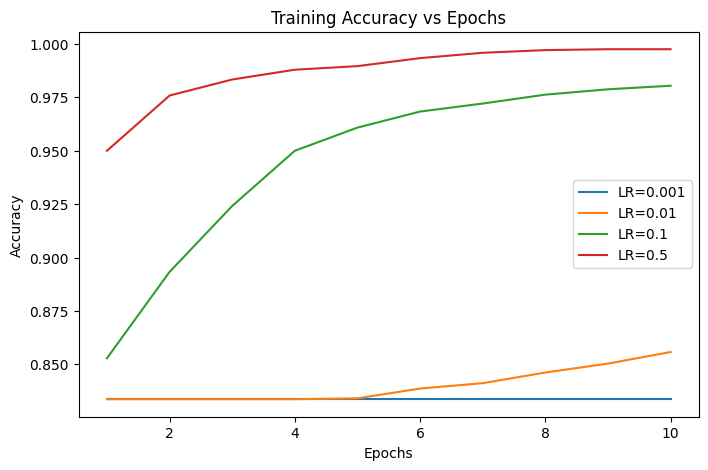

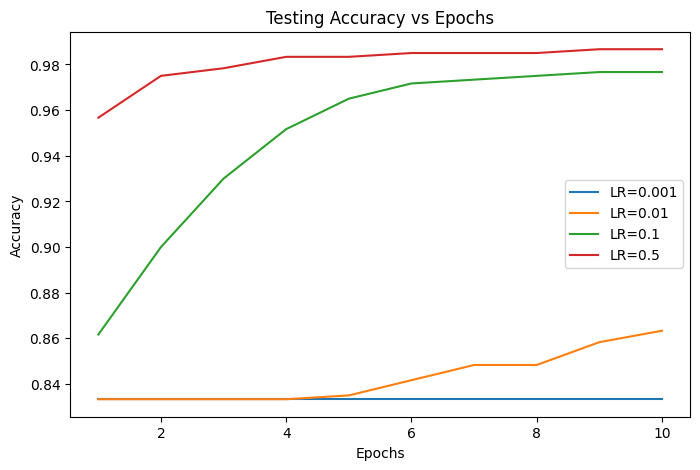

In [39]:
plt.figure(figsize=(8,5))
for lr in learning_rates:
    plt.plot(range(1, epochs+1), train_acc_history[lr], label=f"LR={lr}")
plt.title("Training Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
for lr in learning_rates:
    plt.plot(range(1, epochs+1), test_acc_history[lr], label=f"LR={lr}")
plt.title("Testing Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plotting Training & Testing Loss

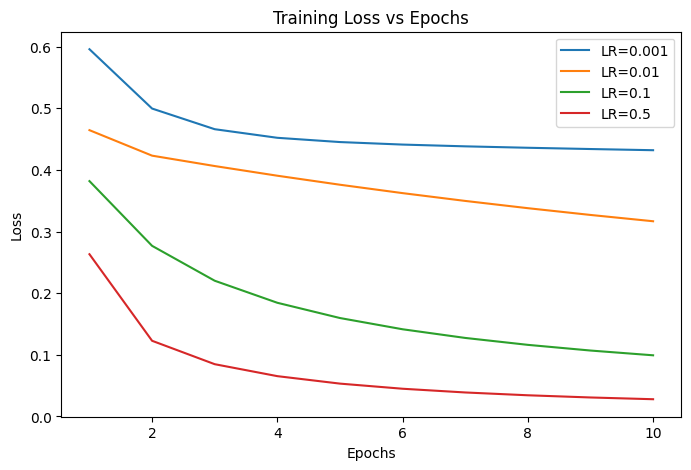

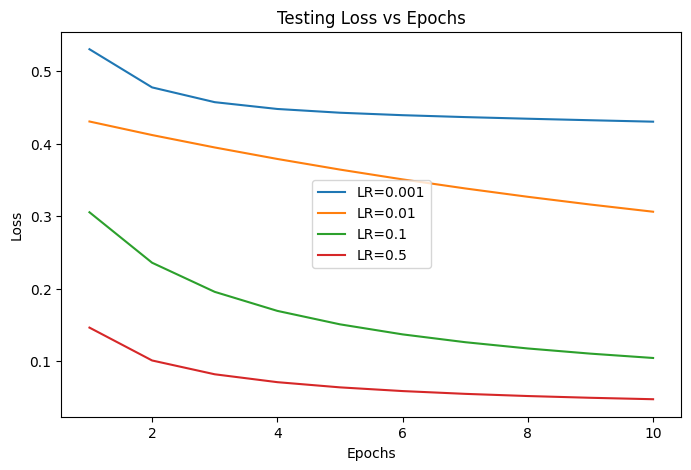

In [40]:
plt.figure(figsize=(8,5))
for lr in learning_rates:
    plt.plot(range(1, epochs+1), train_loss_history[lr], label=f"LR={lr}")
plt.title("Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
for lr in learning_rates:
    plt.plot(range(1, epochs+1), test_loss_history[lr], label=f"LR={lr}")
plt.title("Testing Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Evaluation + Confusion Matrix


 FINAL EVALUATION FOR ALL LEARNING RATES 

Learning Rate = 0.001
Accuracy : 0.8333333333333334
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
----------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


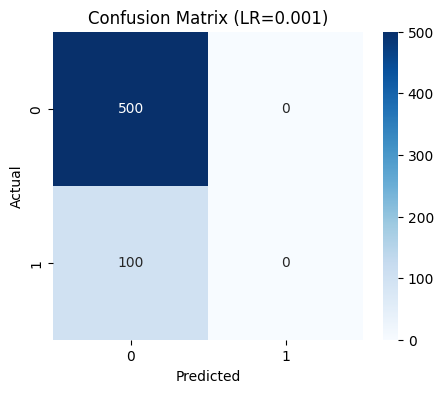

Learning Rate = 0.01
Accuracy : 0.8633333333333333
Precision: 1.0
Recall   : 0.18
F1 Score : 0.3050847457627119
----------------------------------------------------


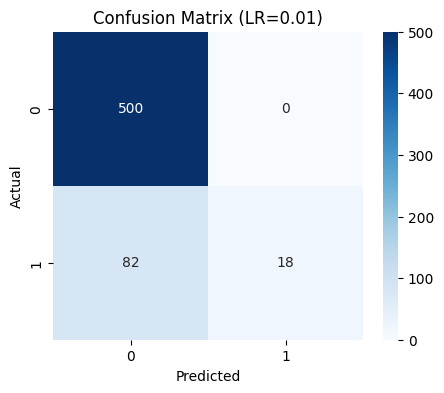

Learning Rate = 0.1
Accuracy : 0.9766666666666667
Precision: 1.0
Recall   : 0.86
F1 Score : 0.9247311827956989
----------------------------------------------------


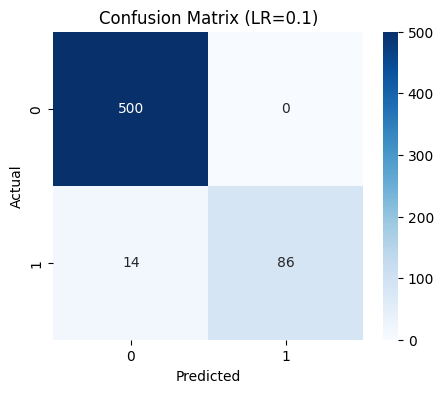

Learning Rate = 0.5
Accuracy : 0.9866666666666667
Precision: 1.0
Recall   : 0.92
F1 Score : 0.9583333333333334
----------------------------------------------------


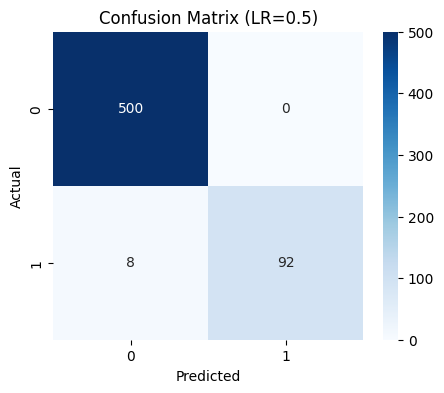

In [41]:
print("\n FINAL EVALUATION FOR ALL LEARNING RATES \n")

for lr in learning_rates:

    w, b = final_models[lr]

    test_probs = sigmoid(np.dot(X_test_tfidf, w) + b)
    test_preds = [1 if i >= 0.5 else 0 for i in test_probs]

    print(f"Learning Rate = {lr}")
    print("Accuracy :", accuracy_score(y_test, test_preds))
    print("Precision:", precision_score(y_test, test_preds))
    print("Recall   :", recall_score(y_test, test_preds))
    print("F1 Score :", f1_score(y_test, test_preds))
    print("----------------------------------------------------")

    # 🔥 Confusion Matrix
    cm = confusion_matrix(y_test, test_preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix (LR={lr})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()